#### Chain Of Thoughts With RAG
What is Chain-of-Thought (CoT) in RAG?

CoT reasoning breaks down a complex question into intermediate steps, and allows retrieval + reflection at each step before answering.

User Query
   ↓
- Step 1: Decompose question → sub-steps (Reason)
- Step 2: Retrieve docs per step (Act)
- Step 3: Combine context (Observe)
- Step 4: Final answer generation (Reflect)

In [24]:
import os
from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_classic.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END,START
from langchain_ollama import OllamaEmbeddings

In [25]:
docs =TextLoader("research_notes.txt", encoding='utf-8').load()
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks=splitter.split_documents(docs)
embeddings=OllamaEmbeddings(model="llama3.2:latest")
vectorstore=FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)
retriever=vectorstore.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000249CFF4CFD0>, search_kwargs={})

In [26]:
from langchain_ollama import ChatOllama
llm=ChatOllama(model="llama3.2:latest")
llm.invoke("hi")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-30T14:33:09.723036Z', 'done': True, 'done_reason': 'stop', 'total_duration': 245794300, 'load_duration': 123466000, 'prompt_eval_count': 26, 'prompt_eval_duration': 17295900, 'eval_count': 8, 'eval_duration': 94746700, 'model_name': 'llama3.2:latest'}, id='lc_run--019ddece-d264-7392-84e0-1b7f68bf9a08-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34})

In [27]:
class RAGCoTstate(BaseModel):
    question:str
    retrieved_docs:List[Document]=[]
    sub_step:List[str]=[]
    answer:str=""
    
    

### Nodes

In [28]:
def plan_step(state:RAGCoTstate):
    prompt=f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result=llm.invoke(prompt).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip()]
    return state.model_copy(update={"sub_step":subqs})

In [29]:
def retrieve_per_step(state:RAGCoTstate):
    retrieved_docs=[]
    for sub_q in state.sub_step:
        docs=retriever.invoke(sub_q)
        retrieved_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs":retrieved_docs})

In [30]:
def generate_answer(state:RAGCoTstate):
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

### Graph

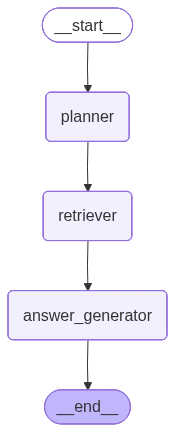

In [31]:
builder=StateGraph(RAGCoTstate)
builder.add_node("planner",plan_step)
builder.add_node("retriever",retrieve_per_step)
builder.add_node("answer_generator",generate_answer)

builder.add_edge(START,"planner")
builder.add_edge("planner","retriever")
builder.add_edge("retriever","answer_generator")
builder.add_edge("answer_generator",END)

graph=builder.compile()
graph

In [32]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the additional eperiments in Transformer eveluation?"
    state = RAGCoTstate(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_step"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['Here are 3 reasoning steps to answer the question:', '**Step 1: Identify the main evaluation metrics for Transformers**', 'Transformers are evaluated using a variety of metrics, including but not limited to:', 'Perplexity', 'Accuracy', 'BLEU score (for machine translation)', 'ROUGE score (for text summarization)', 'However, these metrics may not capture all aspects of Transformer performance.', '**Step 2: Recognize the limitations of traditional evaluation methods**', "Traditional evaluation methods for NLP models like Transformers often focus on specific tasks or datasets. However, they might not provide a comprehensive picture of the model's overall performance.", 'For example:', 'Perplexity can be low for well-performing models but may not capture nuances in understanding or common sense.', "Accuracy and BLEU score are task-specific metrics that don't necessarily generalize to other domains.", '**Step 3: Identify additional experiments for more comprehensive ev